# Apple Stock Price Prediction (Next 30 Days)

## Project Objective

The primary objective of this project is to develop a predictive model that forecasts Apple stock prices for the next 30 days using historical stock data from 2012 to 2019.  
This model will help investors, traders, and financial analysts make informed decisions based on stock trends and potential market movements.


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
import joblib

## Load Dataset


In [2]:
data = pd.read_csv("P675 DATASET.csv")
print(data.head())
print(data.info())

         Date       Open       High        Low      Close  Adj Close    Volume
0  2012-01-03  58.485714  58.928570  58.428570  58.747143  50.765709  75555200
1  2012-01-04  58.571430  59.240002  58.468571  59.062859  51.038536  65005500
2  2012-01-05  59.278572  59.792858  58.952858  59.718571  51.605175  67817400
3  2012-01-06  59.967144  60.392857  59.888573  60.342857  52.144630  79573200
4  2012-01-09  60.785713  61.107143  60.192856  60.247143  52.061932  98506100
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 110.1+

## Data Cleaning

In [3]:
# Convert Date column
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Remove duplicates
data = data.drop_duplicates()

# Handle missing values
data = data.ffill()

# Check summary
print(data.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


### Outlier Detection

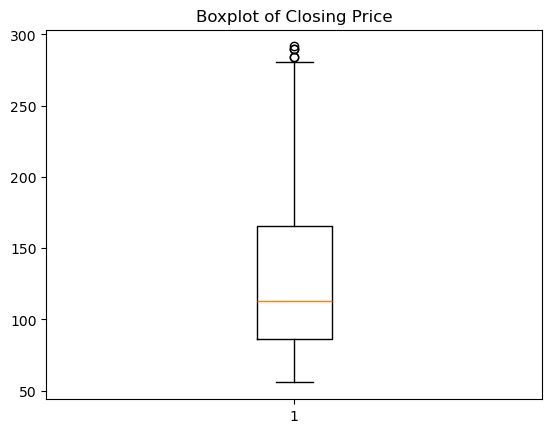

In [4]:
plt.boxplot(data['Close'])
plt.title("Boxplot of Closing Price")
plt.show()

## Exploratory Data Analysis (EDA)

### Trend Plot 

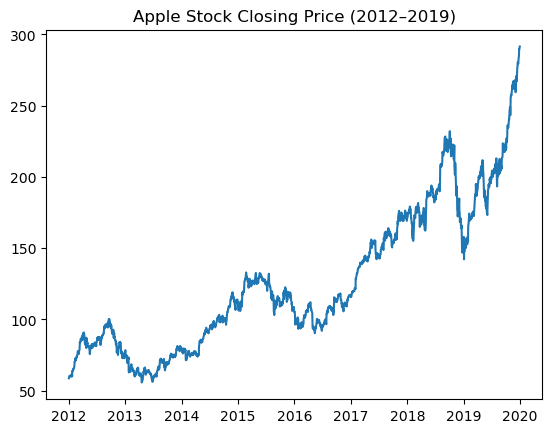

In [5]:
plt.plot(data['Date'], data['Close'])
plt.title('Apple Stock Closing Price (2012–2019)')
plt.show()

### Histograms

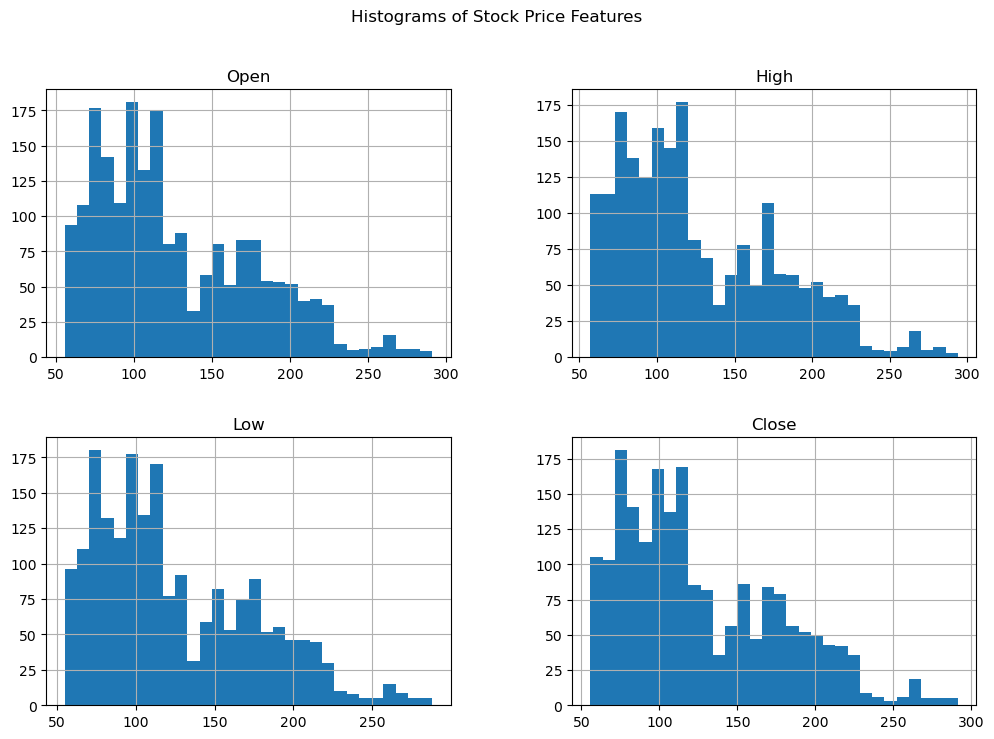

In [6]:
data[['Open','High','Low','Close']].hist(figsize=(12,8), bins=30)
plt.suptitle("Histograms of Stock Price Features")
plt.show()


### Correlation Matrix

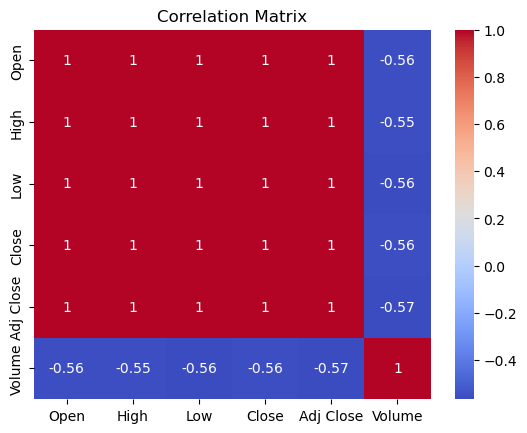

In [7]:
corr = data[['Open','High','Low','Close','Adj Close','Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


## Decomposition

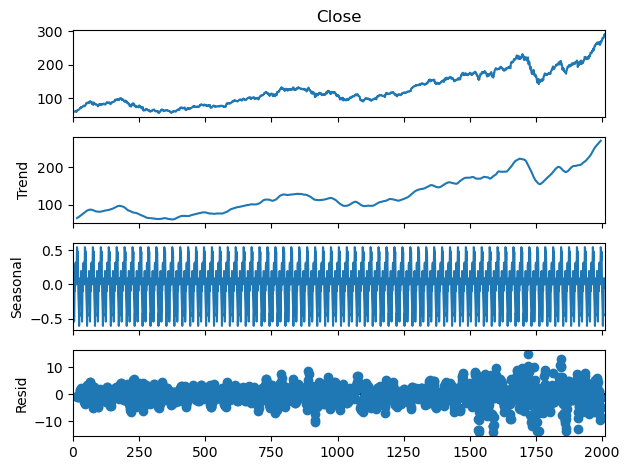

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data['Close'], model='additive', period=30)
result.plot()
plt.show()


## ADF Test

In [9]:
result = adfuller(data['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] > 0.05:
    print("Series is non-stationary → need differencing (d=1)")
else:
    print("Series is stationary → d=0")


ADF Statistic: 1.2193701254378022
p-value: 0.9961170178032009
Series is non-stationary → need differencing (d=1)


## Differencing 

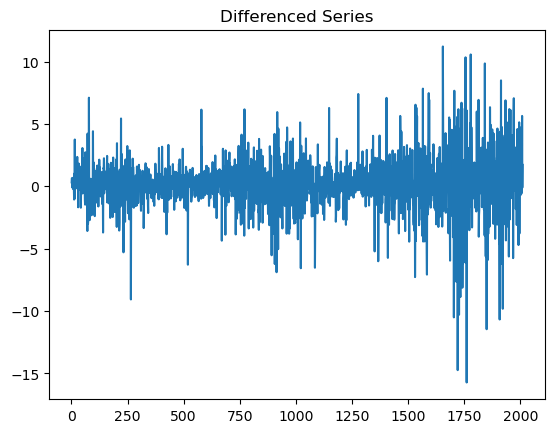

In [10]:
data['Close_diff'] = data['Close'].diff().dropna()
plt.plot(data['Close_diff'])
plt.title("Differenced Series")
plt.show()


## Lag Plots

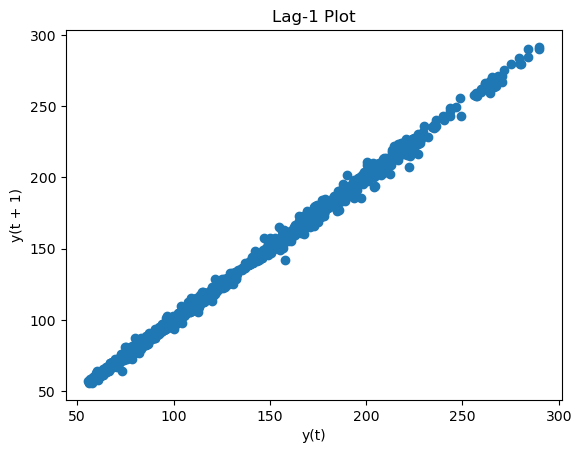

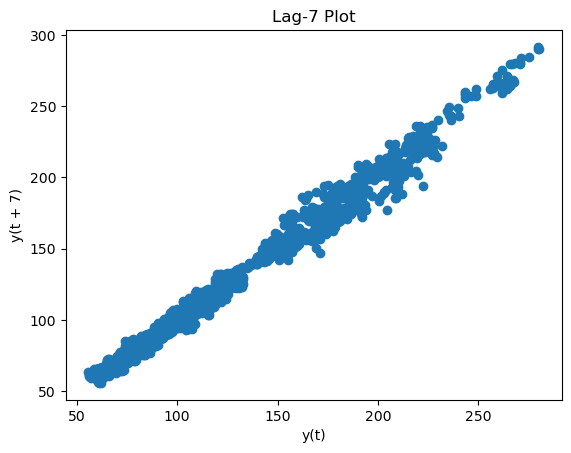

In [11]:
from pandas.plotting import lag_plot
lag_plot(data['Close'], lag=1)
plt.title("Lag-1 Plot")
plt.show()

lag_plot(data['Close'], lag=7)
plt.title("Lag-7 Plot")
plt.show()


## ACF & PACF

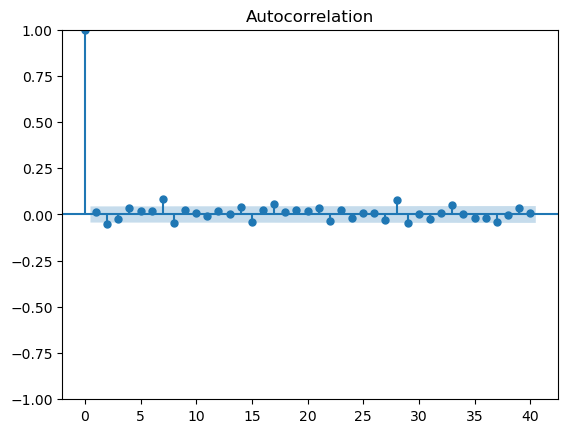

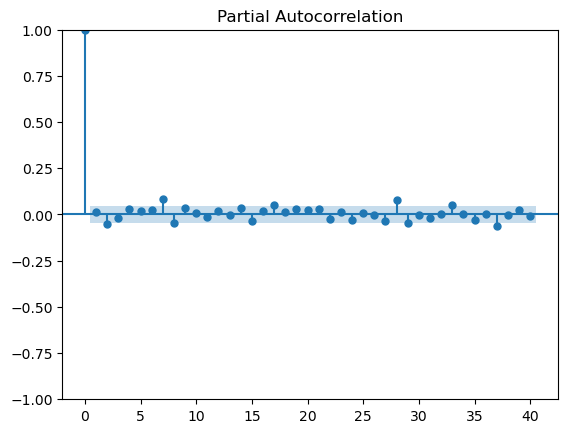

In [12]:
plot_acf(data['Close'].diff().dropna(), lags=40)
plt.show()

plot_pacf(data['Close'].diff().dropna(), lags=40)
plt.show()


## Auto ARIMA

In [13]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [14]:
from pmdarima import auto_arima

# Auto ARIMA model selection
auto_model = auto_arima(data['Close'], 
                        seasonal=False,   
                        stepwise=True, 
                        suppress_warnings=True)

print(auto_model.summary())

# Forecast next 30 days
forecast_auto = auto_model.predict(n_periods=30)
print(forecast_auto)
print(auto_model.order)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2011
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4368.981
Date:                Wed, 17 Jun 2026   AIC                           8741.963
Time:                        16:36:28   BIC                           8753.175
Sample:                             0   HQIC                          8746.078
                               - 2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1158      0.048      2.413      0.016       0.022       0.210
sigma2         4.5239      0.070     64.796      0.000       4.387       4.661
Ljung-Box (L1) (Q):                   0.25   Jarque-

## ARIMA

In [15]:
# ARIMA model 
arima_model = ARIMA(data['Close'], order=(0,1,0))
fit_arima = arima_model.fit()

# Forecast next 30 days
forecast_arima = fit_arima.forecast(steps=30)

## Auto SARIMA

In [16]:
from pmdarima import auto_arima

# Auto SARIMA model selection
auto_sarima = auto_arima(data['Close'],
                         seasonal=True, 
                         m=7,             
                         stepwise=True,
                         suppress_warnings=True)

print(auto_sarima.summary())

# Forecast next 30 days
forecast_auto_sarima = auto_sarima.predict(n_periods=30)
print(forecast_auto_sarima)
print("Selected Order:", auto_sarima.order)
print("Selected Seasonal Order:", auto_sarima.seasonal_order)


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 2011
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 7)   Log Likelihood               -4353.036
Date:                             Wed, 17 Jun 2026   AIC                           8722.073
Time:                                     16:43:03   BIC                           8766.920
Sample:                                          0   HQIC                          8738.536
                                            - 2011                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0374      0.024      1.551      0.121      -0.010       0.085
ar.L1          0.5165      

## SARIMA

In [17]:
sarima_model = SARIMAX(data['Close'], order=(2,1,2), seasonal_order=(1,0,1,7))
fit_sarima = sarima_model.fit()

# Forecast next 30 days
forecast_sarima = fit_sarima.forecast(steps=30)


## XGBoost

### Feature Engineering (XGBoost)

In [18]:
# Feature Engineering
data['Lag_1'] = data['Close'].shift(1)   
data['Lag_7'] = data['Close'].shift(7)
data['MA_30'] = data['Close'].rolling(window=30).mean()
data['Volatility'] = data['Close'].rolling(window=30).std()

X = data[['Lag_1','Lag_7','MA_30','Volatility']].dropna()
y = data['Close'].iloc[-len(X):]



### Hyperparameter Tuning

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 1]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3
)

grid_search.fit(X, y)
print("Best Parameters:", grid_search.best_params_)

best_xgb = grid_search.best_estimator_


Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1}


## Model Evaluation (Train-test split)

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# ------------------------------
# Train-test split (80-20)
# ------------------------------
train_size = int(len(data['Close']) * 0.8)
train, test = data['Close'][:train_size], data['Close'][train_size:]

# ------------------------------
# ARIMA Evaluation
# ------------------------------
arima_model = ARIMA(train, order=(0,1,0))  
fit_arima = arima_model.fit()
forecast_arima = fit_arima.forecast(steps=len(test))

rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mae_arima = mean_absolute_error(test, forecast_arima)

# ------------------------------
# SARIMA Evaluation
# ------------------------------
sarima_model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,0,1,7))  
fit_sarima = sarima_model.fit()
forecast_sarima = fit_sarima.forecast(steps=len(test))

rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
mae_sarima = mean_absolute_error(test, forecast_sarima)

# ------------------------------
# XGBoost Evaluation
# ------------------------------
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
mae_xgb = mean_absolute_error(y_test, y_pred)

# ------------------------------
# Print Results
# ------------------------------
print("ARIMA RMSE:", rmse_arima, "MAE:", mae_arima)
print("SARIMA RMSE:", rmse_sarima, "MAE:", mae_sarima)
print("XGBoost RMSE:", rmse_xgb, "MAE:", mae_xgb)


ARIMA RMSE: 34.05952613304271 MAE: 25.409280121588083
SARIMA RMSE: 33.87031938300985 MAE: 25.241031165867916
XGBoost RMSE: 33.771768470187936 MAE: 23.233834057053883


## Best Model Selection
Results:
ARIMA → RMSE ≈ 34.05, MAE ≈ 25.40

SARIMA → RMSE ≈ 33.87, MAE ≈ 25.24

XGBoost → RMSE ≈ 33.77, MAE ≈ 23.23 
### Best Model → XGBoost.
### XGBoost performed best.

## Retrain Full Dataset & Forecast Next 30 Days

### Retrain ARIMA

In [21]:
from statsmodels.tsa.arima.model import ARIMA

# Retrain ARIMA on full dataset
arima_model = ARIMA(data['Close'], order=(0,1,0))
fit_arima = arima_model.fit()

# Forecast next 30 days
forecast_arima = fit_arima.forecast(steps=30)


### Retrain SARIMA

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Retrain SARIMA on full dataset
sarima_model = SARIMAX(data['Close'], order=(2,1,2), seasonal_order=(1,0,1,7))
fit_sarima = sarima_model.fit()

# Forecast next 30 days
forecast_sarima = fit_sarima.forecast(steps=30)


### Retrain XGBoost

In [23]:
# Retrain XGBoost on full dataset using best parameters
best_xgb.fit(X, y)
    

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Iterative forecasting for next 30 days


In [24]:
# Iterative forecasting for next 30 days using retrained XGBoost
future_preds = []
history = list(data['Close'].values)

for i in range(30):
    # Create lag features dynamically
    lag_1 = history[-1]
    lag_7 = history[-7] if len(history) >= 7 else lag_1
    ma_30 = np.mean(history[-30:]) if len(history) >= 30 else np.mean(history)
    vol_30 = np.std(history[-30:]) if len(history) >= 30 else np.std(history)
    
    # Prepare feature set for prediction
    next_features = pd.DataFrame([[lag_1, lag_7, ma_30, vol_30]],
                                 columns=['Lag_1','Lag_7','MA_30','Volatility'])
    
    # Predict next day closing price
    next_pred = best_xgb.predict(next_features)[0]
    future_preds.append(next_pred)
    
    # Add prediction to history for next iteration
    history.append(next_pred)

# Final forecast for next 30 days
forecast_xgb = future_preds

## Forecast Visualization

### Forecast comparison of ARIMA,SARIMA,XGBoost Models 
##### We plot actual last 100 days vs forecasted next 30 days for ARIMA, SARIMA, and XGBoost.


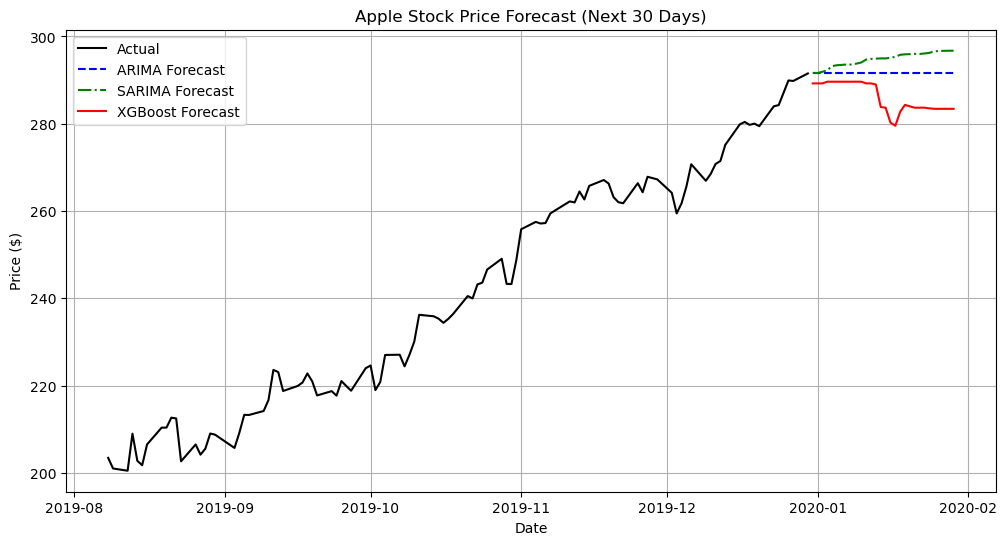

In [25]:
# Future dates (next 30 days)
future_dates = pd.date_range(start=data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=30)

# Plot actual last 100 days + next 30 days forecasts
plt.figure(figsize=(12,6))

# Actual last 100 days
plt.plot(data['Date'].tail(100), data['Close'].tail(100), label='Actual', color='black')

# Forecasts (slice to 30 steps)
plt.plot(future_dates, forecast_arima[:30], label='ARIMA Forecast', linestyle='--', color='blue')
plt.plot(future_dates, forecast_sarima[:30], label='SARIMA Forecast', linestyle='-.', color='green')
plt.plot(future_dates, forecast_xgb[:30], label='XGBoost Forecast', linestyle='-', color='red')

# Formatting
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("Apple Stock Price Forecast (Next 30 Days)")
plt.legend()
plt.grid(True)
plt.show()


## Final XGBoost Forecast Visualization (Training, Testing & Predicted Values)


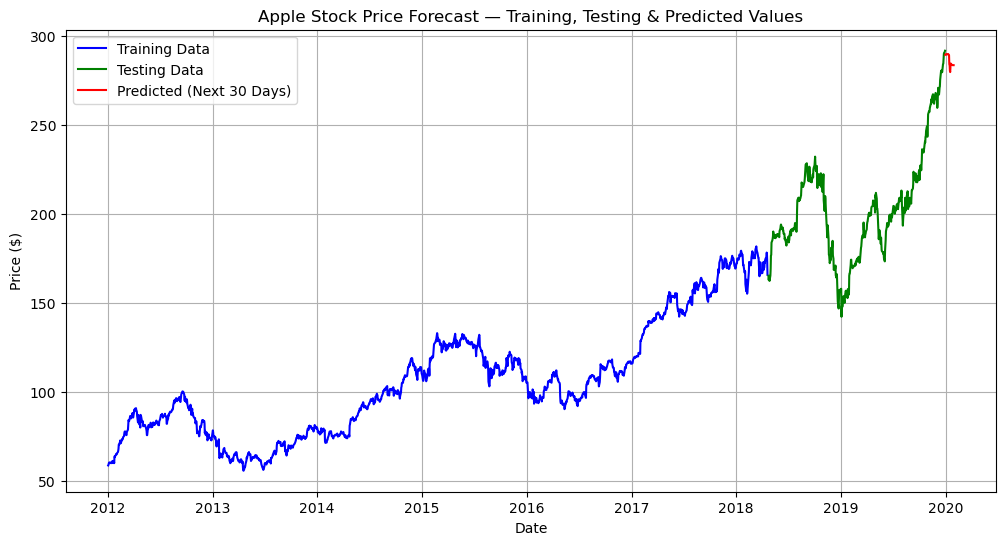

In [26]:
plt.figure(figsize=(12,6))

# Training data
plt.plot(data['Date'][:train_size], data['Close'][:train_size], label='Training Data', color='blue')

# Testing data
plt.plot(data['Date'][train_size:], data['Close'][train_size:], label='Testing Data', color='green')

# Predicted (XGBoost forecast)
future_dates = pd.date_range(start=data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=30)
plt.plot(future_dates, forecast_xgb, label='Predicted (Next 30 Days)', color='red')

# Formatting
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("Apple Stock Price Forecast — Training, Testing & Predicted Values")
plt.legend()
plt.grid(True)
plt.show()


## Conclusion

In this project, Apple stock prices (2012–2019) were analyzed and forecasted using ARIMA, SARIMA, and XGBoost models.  
- ARIMA (0,1,0) produced a simple random walk model with limited accuracy.  
- SARIMA (2,1,2)(1,0,1,7) captured seasonal patterns better but still showed moderate error.  
- XGBoost, with engineered lag, moving average, and volatility features, achieved the **lowest error (RMSE ≈ 33.77, MAE ≈ 23.23)**, outperforming statistical models.  

After hyperparameter tuning and retraining on the full dataset, XGBoost generated a reliable 30‑day forecast.  
The final visualizations clearly demonstrate training, testing, and predicted values, highlighting the robustness of the chosen model.  

**Therefore, XGBoost is selected as the best model for deployment.**  
The saved model (`xgb_model.pkl`) is ready to be integrated into a Streamlit application for real‑time forecasting and investor decision support.


### Save Model for Deployment

In [27]:
import joblib
joblib.dump(best_xgb, "xgb_model.pkl")


['xgb_model.pkl']

## Deployment

#### Terminal Command : streamlit run "P675 apple stock prediction app.py"

In [28]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
